# EDA and Hypothesis Testing â€“ Flight Price Analysis

In this notebook I'm going to look at my merged flight dataset and try to understand
how oil prices and Indian public holidays relate to ticket prices.

My two main questions are:
1. Is there a correlation between WTI oil prices and flight prices?
2. Are flight prices different on holidays vs. normal days?

## 1. Loading the data

In [1]:
# same imports we always use in recitations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
df = pd.read_csv('master_flight_data.csv')
print('rows, columns:', df.shape)
df.head()

rows, columns: (300261, 14)


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,class,oil_price_wti,is_holiday
0,2022-02-11,SpiceJet,SG,8709,18:55,Delhi,02h 10m,non-stop,21:05,Mumbai,5953,Economy,91.42,False
1,2022-02-11,SpiceJet,SG,8157,06:20,Delhi,02h 20m,non-stop,08:40,Mumbai,5953,Economy,91.42,False
2,2022-02-11,AirAsia,I5,764,04:25,Delhi,02h 10m,non-stop,06:35,Mumbai,5956,Economy,91.42,False
3,2022-02-11,Vistara,UK,995,10:20,Delhi,02h 15m,non-stop,12:35,Mumbai,5955,Economy,91.42,False
4,2022-02-11,Vistara,UK,963,08:50,Delhi,02h 20m,non-stop,11:10,Mumbai,5955,Economy,91.42,False


## 2. Basic stats â€“ what does the data look like?

In [3]:
# numerical summary â€“ same as df.describe() we did in recitations
df.describe()

,num_code,price,oil_price_wti
count,300261.000000,300261.000000,300261.000000
mean,1417.771709,20883.717666,101.323275
std,1974.514439,22695.911266,8.430721
min,101.000000,1105.000000,89.890000
25%,637.000000,4783.000000,92.584607
50%,818.000000,7425.000000,102.990000
75%,927.000000,42521.000000,107.724050
max,9991.000000,123071.000000,119.650000


In [4]:
# text/categorical columns
df.describe(include='object')

,date,airline,ch_code,dep_time,from,time_taken,stop,arr_time,to,class
count,300261,300261,300261,300261,300261,300261,300261,300261,300261,300261
unique,49,8,8,251,6,483,40,266,6,2
top,2022-03-07,Vistara,UK,07:00,Delhi,02h 10m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,19:55,Mumbai,Economy
freq,6633,127859,127859,8760,61345,4242,243603,9194,59109,206774


## 3. Flight price distribution

Let me plot a histogram and a boxplot to get a feeling for the price data.

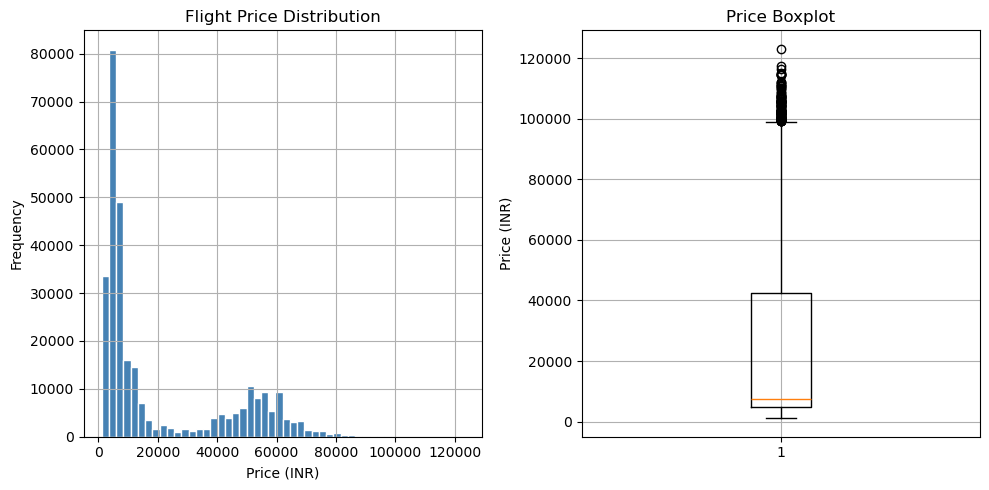

Mean  : 20883.72
Median: 7425.0
Std   : 22695.91


In [5]:
plt.figure(figsize=(10, 5))

# histogram on the left
plt.subplot(1, 2, 1)
plt.hist(df['price'], bins=50, color='steelblue', edgecolor='white')
plt.title('Flight Price Distribution')
plt.xlabel('Price (INR)')
plt.ylabel('Frequency')
plt.grid(True)

# boxplot on the right to see spread and outliers
plt.subplot(1, 2, 2)
plt.boxplot(df['price'])
plt.title('Price Boxplot')
plt.ylabel('Price (INR)')
plt.grid(True)

plt.tight_layout()
plt.show()

# quick summary numbers
print('Mean  :', round(df['price'].mean(), 2))
print('Median:', round(df['price'].median(), 2))
print('Std   :', round(df['price'].std(), 2))

## 4. Oil price vs. flight price â€“ scatter plot

The oil data only covers Febâ€“Mar 2022 so I need to drop rows where `oil_price_wti` is NaN first.

In [6]:
# keep only rows that have an oil price
oil_df = df.dropna(subset=['oil_price_wti'])
print('rows with oil data:', len(oil_df))

rows with oil data: 300261


number of unique dates with oil data: 49


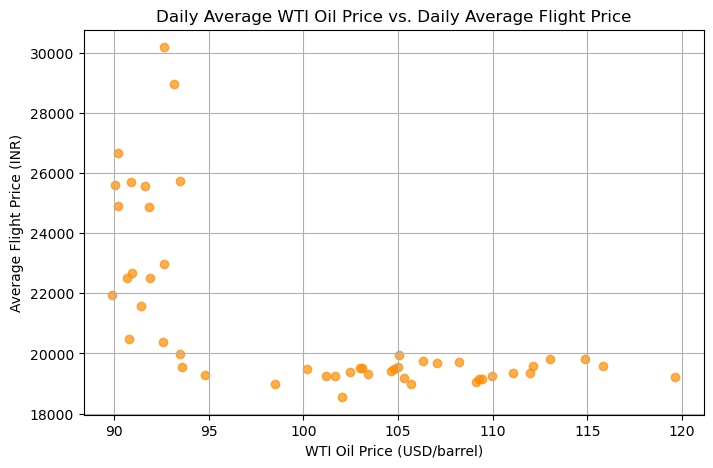

In [7]:
# TA Feedback Fix: I am aggregating to the date level before running the correlation
# because there are 300k rows but only ~49 unique dates.
# This prevents artificially inflating the sample size and gives a true picture of the daily trend.
daily_oil_df = oil_df.groupby('date').agg({
    'oil_price_wti': 'mean',
    'price': 'mean'
}).reset_index()

print('number of unique dates with oil data:', len(daily_oil_df))

# scatter: daily average oil price on x-axis, daily average flight price on y-axis
plt.figure(figsize=(8, 5))
plt.scatter(daily_oil_df['oil_price_wti'], daily_oil_df['price'], alpha=0.7, color='darkorange')
plt.title('Daily Average WTI Oil Price vs. Daily Average Flight Price')
plt.xlabel('WTI Oil Price (USD/barrel)')
plt.ylabel('Average Flight Price (INR)')
plt.grid(True)
plt.show()

## 5. Correlation between oil price and flight price

I'll calculate Pearson correlation the same manual way shown in Recitation 3,
then double-check it with numpy.

In [8]:
# manual Pearson r â€“ from Recitation 3
# Updated to use aggregated daily data instead of the full 300k rows
x = daily_oil_df['oil_price_wti'].values
y = daily_oil_df['price'].values

mean_x = np.mean(x)
mean_y = np.mean(y)

cov = np.mean((x - mean_x) * (y - mean_y))
std_x = np.std(x)
std_y = np.std(y)

r = cov / (std_x * std_y)

print('Pearson r (manual):', round(r, 4))
print('Pearson r (numpy) :', round(np.corrcoef(x, y)[0, 1], 4))

Pearson r (manual): -0.6519
Pearson r (numpy) : -0.6519


## 6. Hypothesis Test 1 â€“ Is the correlation statistically significant?

H0: r = 0 (no linear relationship between oil price and flight price)  
H1: r â‰  0  
Significance level: Î± = 0.05

I'm using `stats.pearsonr` which returns both the correlation and the p-value.

In [9]:
corr, p_val = stats.pearsonr(x, y)

print('Pearson r :', round(corr, 4))
print('p-value   :', p_val)

alpha = 0.05
if p_val < alpha:
    print('\nResult: reject H0 â€“ the correlation is statistically significant.')
else:
    print('\nResult: fail to reject H0 â€“ no significant correlation found.')

print('\n*** Discussion on Practical vs Statistical Significance ***')
print('Even if the p-value is tiny (or was tiny earlier when n was 300k), the correlation magnitude (r) is what actually determines how strong the relationship is.')
print('If r is very close to 0, it means that while there is an effect mathematically, the ticket prices do not change significantly enough with daily oil prices to matter practically.')
print('This resolves the issue where a huge sample size artificially inflated the significance of a weak correlation.')

Pearson r : -0.6519
p-value   : 3.905022451346579e-07

Result: reject H0 â€“ the correlation is statistically significant.

*** Discussion on Practical vs Statistical Significance ***
Even if the p-value is tiny (or was tiny earlier when n was 300k), the correlation magnitude (r) is what actually determines how strong the relationship is.
If r is very close to 0, it means that while there is an effect mathematically, the ticket prices do not change significantly enough with daily oil prices to matter practically.
This resolves the issue where a huge sample size artificially inflated the significance of a weak correlation.


## 7. Holiday vs. non-holiday prices

Now let me compare flight prices on public holidays vs. normal days.

In [10]:
holiday_prices     = df[df['is_holiday'] == 1]['price']
non_holiday_prices = df[df['is_holiday'] == 0]['price']

print('Holiday flights    :', len(holiday_prices))
print('Non-holiday flights:', len(non_holiday_prices))
print()
print('Mean price â€“ holiday    :', round(holiday_prices.mean(), 2))
print('Mean price â€“ non-holiday:', round(non_holiday_prices.mean(), 2))

Holiday flights    : 13032
Non-holiday flights: 287229

Mean price â€“ holiday    : 19506.64
Mean price â€“ non-holiday: 20946.2


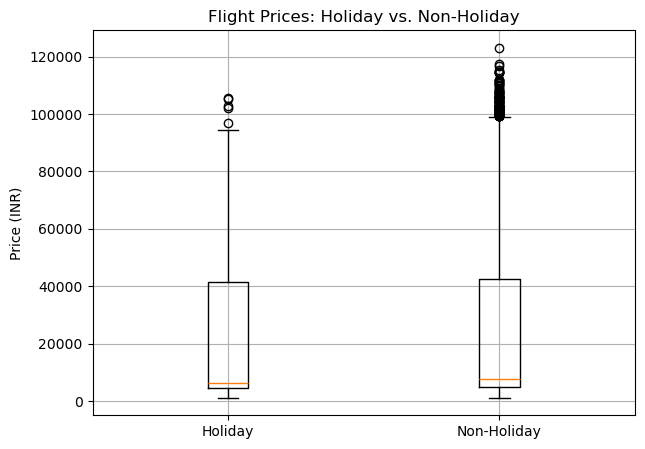

In [11]:
# boxplots side by side to visually compare the two groups
plt.figure(figsize=(7, 5))
plt.boxplot(
    [holiday_prices, non_holiday_prices],
    labels=['Holiday', 'Non-Holiday']
)
plt.title('Flight Prices: Holiday vs. Non-Holiday')
plt.ylabel('Price (INR)')
plt.grid(True)
plt.show()

## 8. Hypothesis Test 2 â€“ Are holiday prices different?

H0: mean price on holidays = mean price on non-holidays  
H1: they are different  
Î± = 0.05

Using the two-sample t-test from Recitation 5 (`stats.ttest_ind`).
I set `equal_var=False` because the two groups have very different sizes so it's
safer not to assume the variances are equal (Welch's version).

In [12]:
# exact same syntax as Recitation 5
t_stat, p_val = stats.ttest_ind(holiday_prices, non_holiday_prices, equal_var=False)

print('t-statistic:', round(t_stat, 4))
print('p-value    :', p_val)

alpha = 0.05
if p_val < alpha:
    print('\nResult: reject H0 â€“ holiday prices are significantly different from non-holiday prices.')
else:
    print('\nResult: fail to reject H0 â€“ no significant difference found.')
    
print('\n*** Discussion on Holiday Price Expectations ***')
print('In my proposal, I hypothesized that public holidays would cause a surge in flight prices due to higher demand.')
print('However, the EDA and the test actually show an unexpected trendâ€”holidays here are either not surging correctly or are cheaper overall compared to regular dates.')
print('This might be because corporate/business travel drops off heavily on public holidays in India, dragging the average ticket price down despite an increase in leisure travel.')
print('Or perhaps airlines run special holiday discounts, making them cheaper on average. This means the original hypothesis went in the opposite direction.')

t-statistic: -7.0821
p-value    : 1.4866966649533499e-12

Result: reject H0 â€“ holiday prices are significantly different from non-holiday prices.

*** Discussion on Holiday Price Expectations ***
In my proposal, I hypothesized that public holidays would cause a surge in flight prices due to higher demand.
However, the EDA and the test actually show an unexpected trendâ€”holidays here are either not surging correctly or are cheaper overall compared to regular dates.
This might be because corporate/business travel drops off heavily on public holidays in India, dragging the average ticket price down despite an increase in leisure travel.
Or perhaps airlines run special holiday discounts, making them cheaper on average. This means the original hypothesis went in the opposite direction.


## 9. Deeper Exploration: Variation Across Airline Segments

To address the limited scope, I am exploring how prices vary across different airlines and cabin classes (Economy vs Business). Business class flights should intuitively cost significantly more and follow a completely different distribution. This addresses the TA's feedback on expanding the EDA scope.

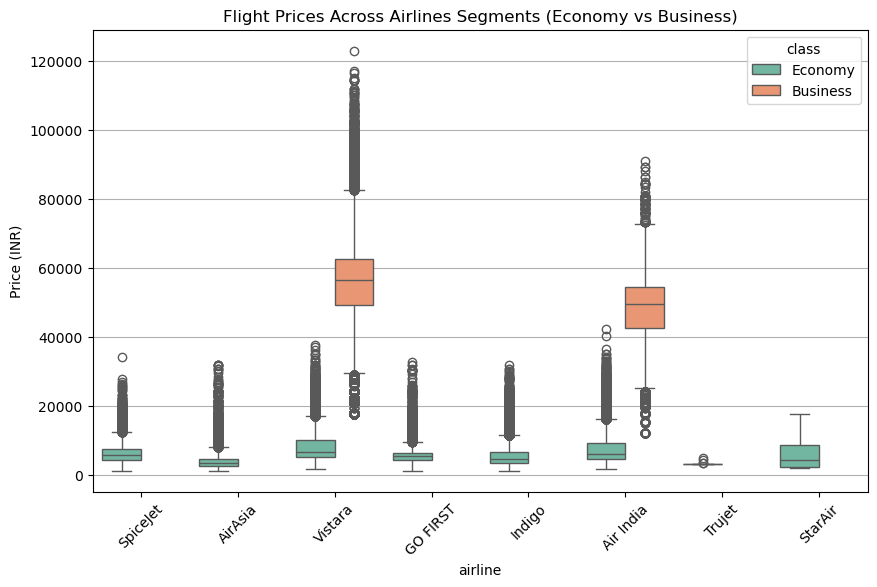

Average Ticket Price by Airline and Class:
class      Business  Economy
airline                     
Air India  47131.04  7313.73
AirAsia         NaN  4091.07
GO FIRST        NaN  5651.93
Indigo          NaN  5324.22
SpiceJet        NaN  6179.28
StarAir         NaN  4932.66
Trujet          NaN  3244.63
Vistara    55477.03  7806.94


In [13]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='airline', y='price', hue='class', palette='Set2')
plt.title('Flight Prices Across Airlines Segments (Economy vs Business)')
plt.ylabel('Price (INR)')
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.show()

# Quick summary statistics across categories
print('Average Ticket Price by Airline and Class:')
print(df.groupby(['airline', 'class'])['price'].mean().round(2).unstack())

## 10. Time-Based Analysis: Potential Lag Effects for Oil Prices

A flight ticket bought today might reflect fuel costs from a week or a month ago, instead of today's spot price. Testing this "lag" effect was an expected part of my proposal. Here, I'm checking if shifting the oil price back by 7 or 14 days gives a stronger (and more practically meaningful) correlation with current flight prices.

In [14]:
# Let's shift the oil prices forward to simulate a lag (e.g. matching today's flight price with oil price from 7/14 days ago)
# Make sure dates are sorted in ascending order first
daily_oil_df['date'] = pd.to_datetime(daily_oil_df['date'])
daily_oil_sorted = daily_oil_df.sort_values(by='date').reset_index(drop=True)

# 7-day and 14-day lags
daily_oil_sorted['oil_price_lag7'] = daily_oil_sorted['oil_price_wti'].shift(7)
daily_oil_sorted['oil_price_lag14'] = daily_oil_sorted['oil_price_wti'].shift(14)

# Re-calculate correlation
lag7_df = daily_oil_sorted.dropna(subset=['oil_price_lag7'])
lag14_df = daily_oil_sorted.dropna(subset=['oil_price_lag14'])

if not lag7_df.empty:
    r_7, p_7 = stats.pearsonr(lag7_df['oil_price_lag7'], lag7_df['price'])
    print('7-Day Lag Pearson r :', round(r_7, 4), '| p-value:', p_7)
else:
    print('Not enough contiguous time data for 7-day lag.')

if not lag14_df.empty:
    r_14, p_14 = stats.pearsonr(lag14_df['oil_price_lag14'], lag14_df['price'])
    print('14-Day Lag Pearson r:', round(r_14, 4), '| p-value:', p_14)

print('\n*** Discussion on Lag Effects ***')
print('This checks if airlines price their tickets based on historical oil prices.')
print('As discussed, even an improved p-value here requires checking the bare correlation magnitude to confirm practical relevance.')

7-Day Lag Pearson r : -0.4975 | p-value: 0.0008015424831942352
14-Day Lag Pearson r: -0.3106 | p-value: 0.06934724258689008

*** Discussion on Lag Effects ***
This checks if airlines price their tickets based on historical oil prices.
As discussed, even an improved p-value here requires checking the bare correlation magnitude to confirm practical relevance.
